In [ ]:
import os
import sys
import glob

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), '../../../'))
# from src.features.create_label_band import visualize_label_band
from utils.utils import get_data_root

In [11]:
def visualize_label_band(labels_path, output_path=None):
    """
    Visualize irrigation labels overlaid on RGB satellite image.
    Adapted from existing visualization code.
    
    Parameters:
        labels_path (str): Path to label .tif file (e.g., "123_456_2020.08.27_labels.tif")
        output_path (str, optional): Where to save figure. If None, displays interactively.
    """
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap
    from matplotlib.path import Path
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize
    from skimage import measure
    from datetime import date, datetime
    import json
    import numpy as np
    import rasterio
    import os
    
    # Parse paths
    labels_dir = os.path.dirname(labels_path)
    labels_file = os.path.basename(labels_path)
    file_id = labels_file.replace('_labels.tif', '')
    
    stack_path = os.path.join(labels_dir, f"{file_id}_stack.tif")
    metadata_path = os.path.join(labels_dir, f"{file_id}_metadata.json")
    
    # Parse survey date from filename
    date_str = file_id.split('_')[2]  # "2020.08.27"
    year, month, day = map(int, date_str.split('.'))
    survey_date = date(year, month, day)
    
    # Load metadata to find timestep
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    # Find matching timestep
    timestep_idx = None
    for i, window in enumerate(metadata['windows']):
        start = datetime.strptime(window['date_range'][0], '%Y-%m-%d').date()
        end = datetime.strptime(window['date_range'][1], '%Y-%m-%d').date()
        if start <= survey_date <= end:
            timestep_idx = i
            break
    
    if timestep_idx is None:
        timestep_idx = len(metadata['windows']) // 2
    
    # Load RGB for this timestep (B4=red, B3=green, B2=blue = indices 2,1,0)
    num_bands = len(metadata['bands'])
    with rasterio.open(stack_path) as src:
        # Read entire stack
        stack_data = src.read()

    # Reshape to (T, B, H, W)
    T = stack_data.shape[0] // num_bands
    H, W = stack_data.shape[1], stack_data.shape[2]
    stack = stack_data.reshape(num_bands, T, H, W).transpose(1, 0, 2, 3)

    # Extract RGB for the timestep: [B4, B3, B2] = [2, 1, 0]
    rgb_indices = [2, 1, 0]
    rgb = stack[timestep_idx, rgb_indices, :, :]
    rgb = np.transpose(rgb, (1, 2, 0))
    rgb = np.clip(rgb / 3000.0, 0, 1)
    
    # Load labels
    with rasterio.open(labels_path) as src:
        labels = src.read()  # Shape: (8, H, W)
    
    # Define colormaps
    colors = ['black', 'blue', 'green', 'yellow', 'orange', 'red']
    
    band_dict = {
        1: "Categorical Irrigation Type",
        2: "Binary Irrigation",
        3: "Uncertainty: Unclear agriculture",
        4: "Uncertainty: Only slightly green",
        5: "Uncertainty: Uneven",
        6: "Uncertainty: May be natural",
        7: "Uncertainty: May be fishpond",
        8: "Certainty score"
    }
    
    # Create figure with 8 subplots
    fig, axes = plt.subplots(4, 2, figsize=(12, 18))
    axes = axes.flatten()
    fig.suptitle(f"Irrigation Labels - {file_id}\n{survey_date.strftime('%Y-%m-%d')}", 
                 fontsize=16, fontweight='bold')
    
    # Plot each band
    for i in range(8):
        ax = axes[i]
        
        # Show RGB background
        ax.imshow(rgb)
        
        label_band = labels[i]
        
        # Determine number of colors for this band
        len_colors = len(colors) if i in [0, 7] else 2
        cmap = ListedColormap(colors[:len_colors])
        
        # Draw outlines around labeled regions
        contours = measure.find_contours(label_band, level=0.5)
        
        for contour in contours:
            path = Path(contour)
            
            # Get all pixel coordinates
            y, x = np.mgrid[0:label_band.shape[0], 0:label_band.shape[1]]
            coords = np.vstack((y.flatten(), x.flatten())).T
            
            # Find pixels inside the contour
            inside = path.contains_points(coords).reshape(label_band.shape)
            vals_inside = label_band[inside]
            vals_inside = vals_inside[vals_inside > 0]
            
            if len(vals_inside) == 0:
                continue
            
            # Find the most common class (dominant value)
            cls = np.bincount(vals_inside.astype(int)).argmax()
            
            # Get corresponding color from cmap
            color = cmap(cls / (len_colors - 1))[:3]
            
            # Draw the outline
            ax.plot(contour[:, 1], contour[:, 0], color=color, linewidth=2)
        
        # Add colorbar
        mappable = ScalarMappable(norm=Normalize(vmin=0, vmax=len_colors - 1), cmap=cmap)
        cbar = fig.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04, ticks=range(len_colors))
        
        ax.set_title(f'Band {i+1}: {band_dict[i+1]}', fontsize=10)
        ax.axis('off')
    
    plt.tight_layout()
    
    if output_path:
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {output_path}")
    else:
        plt.show()
    
    plt.close()
    return fig

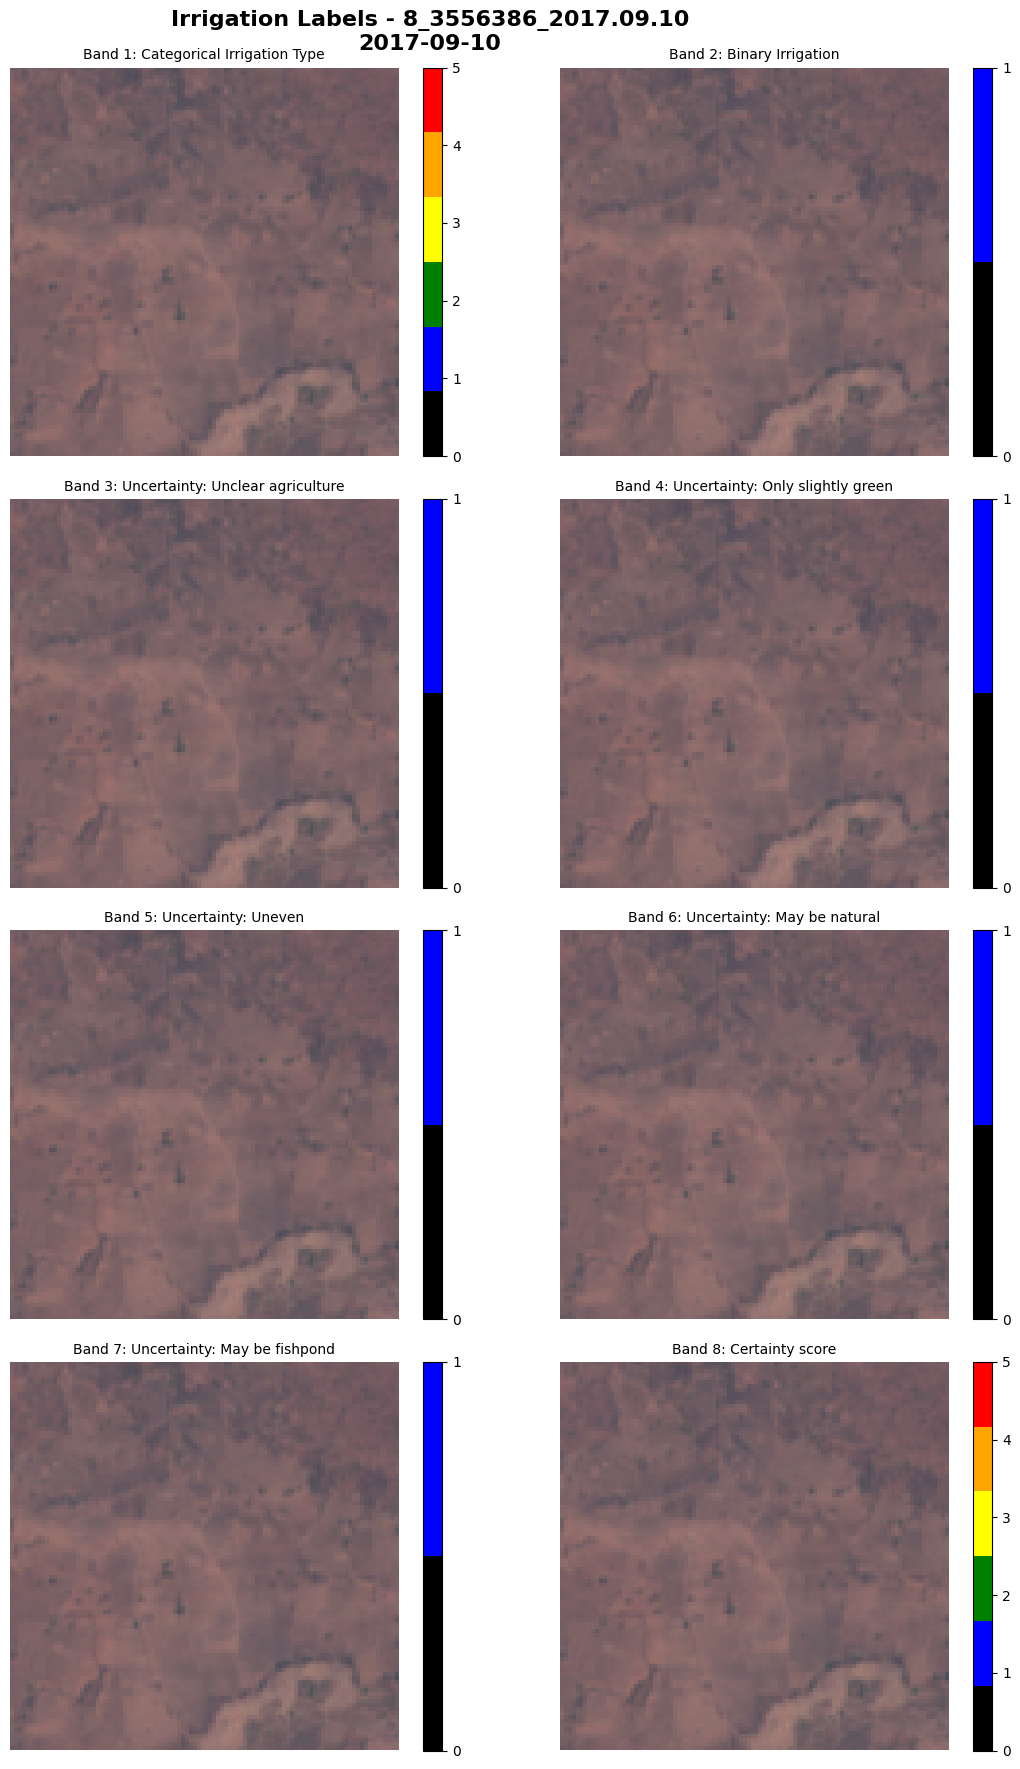

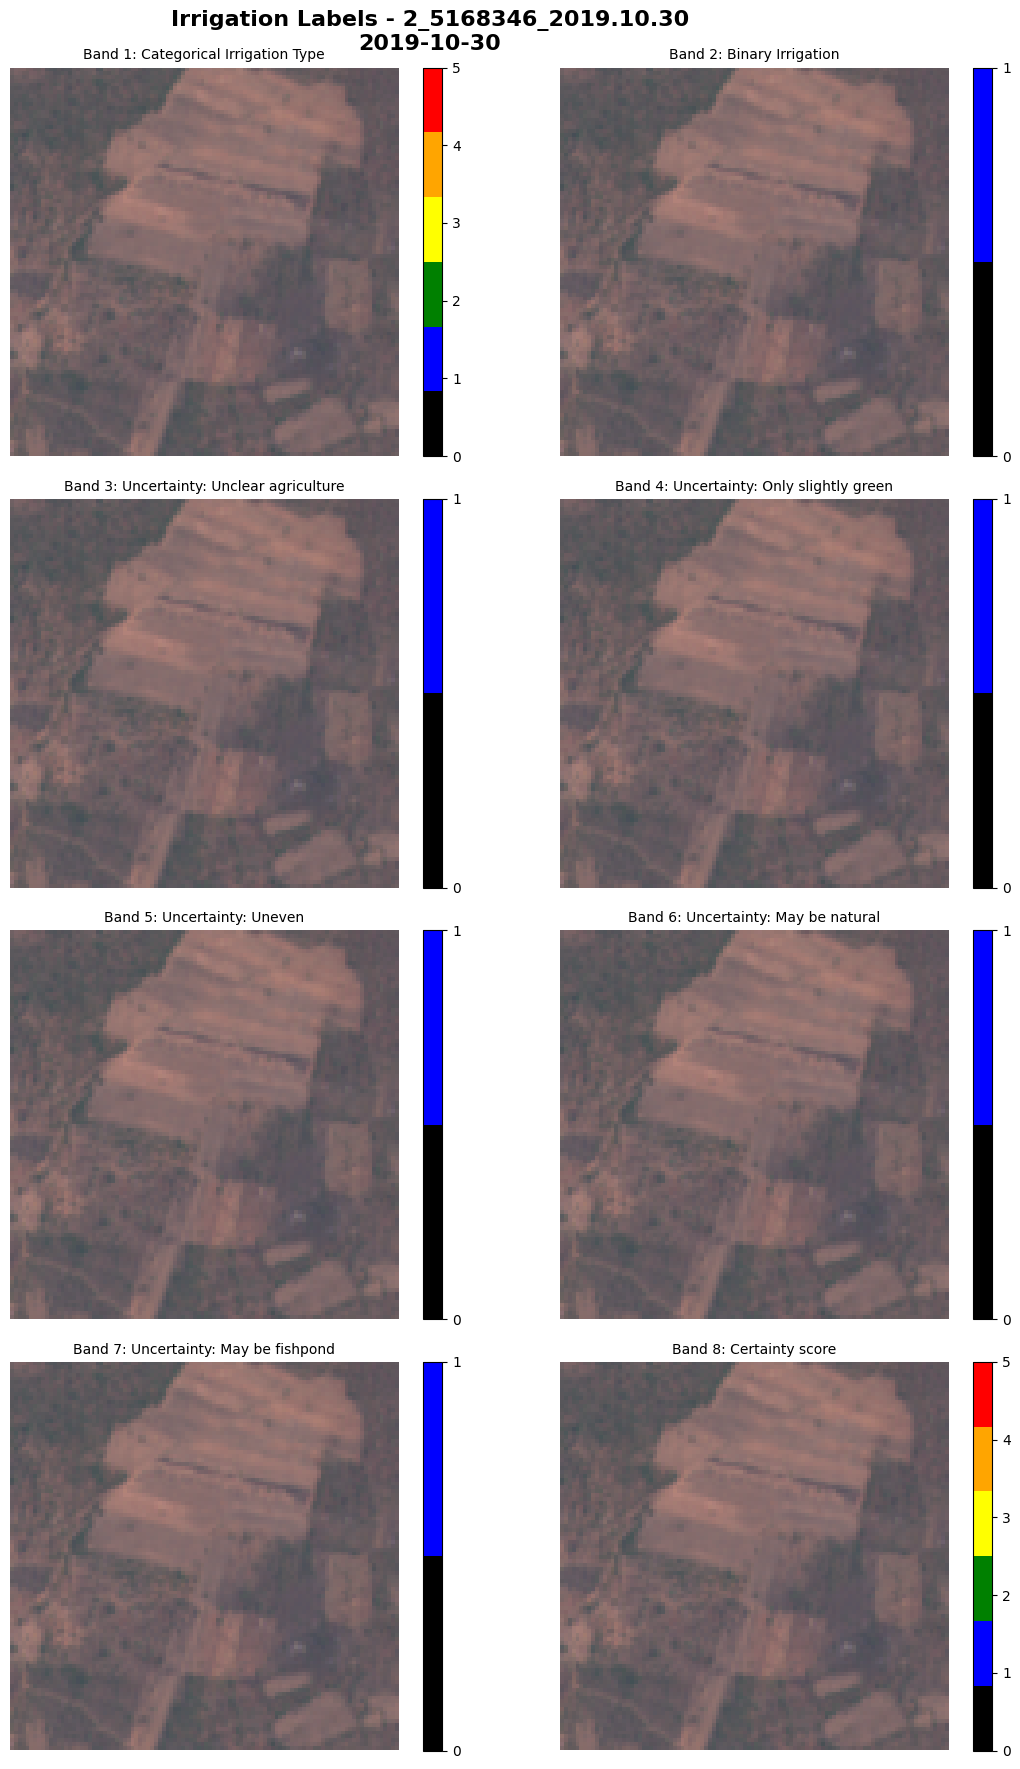

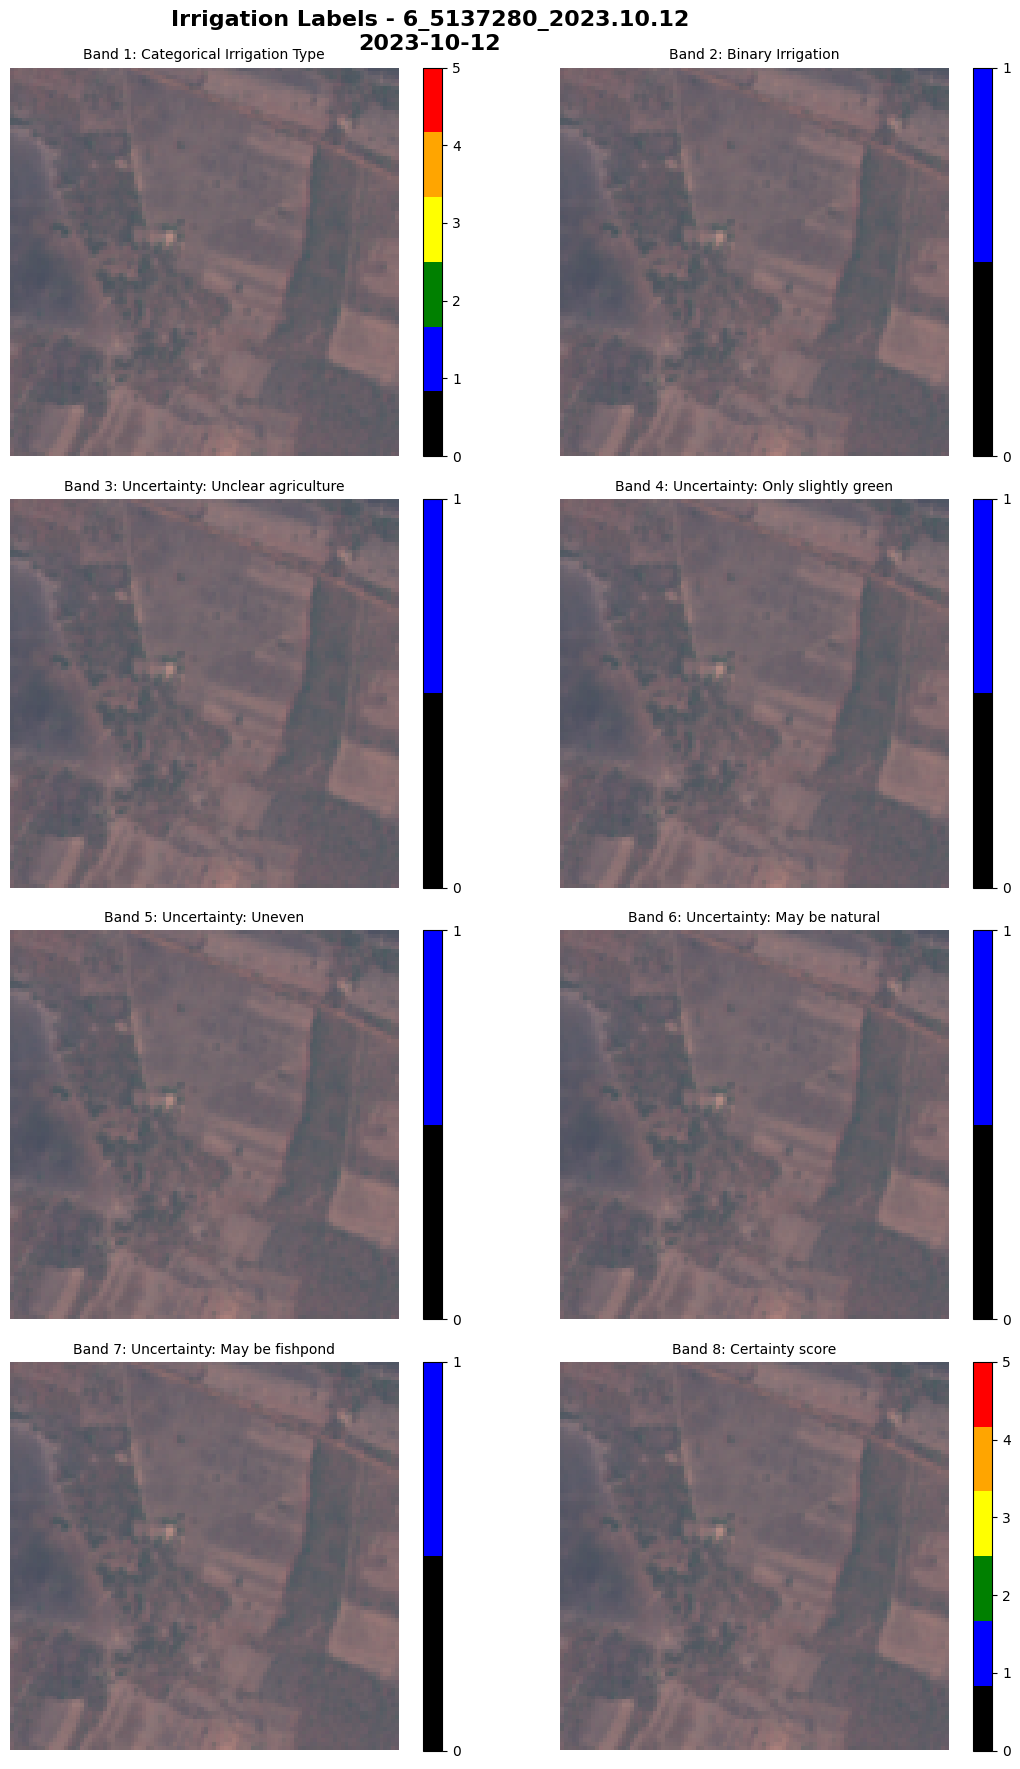

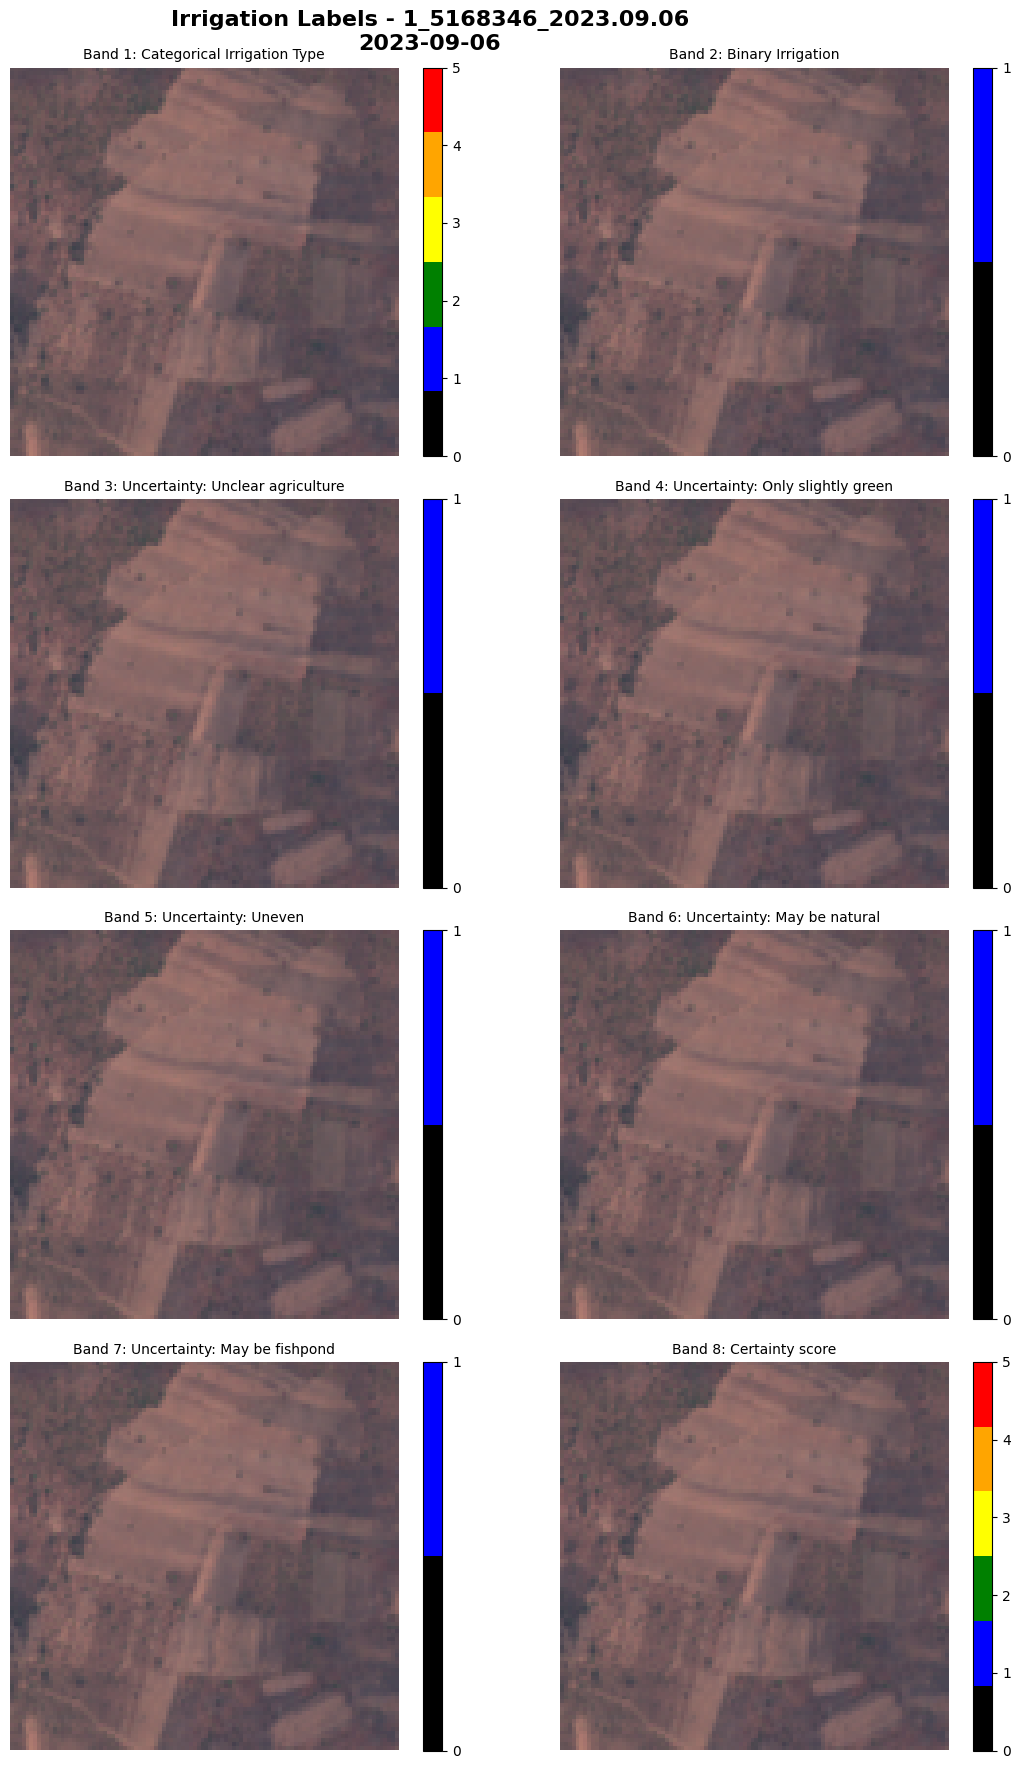

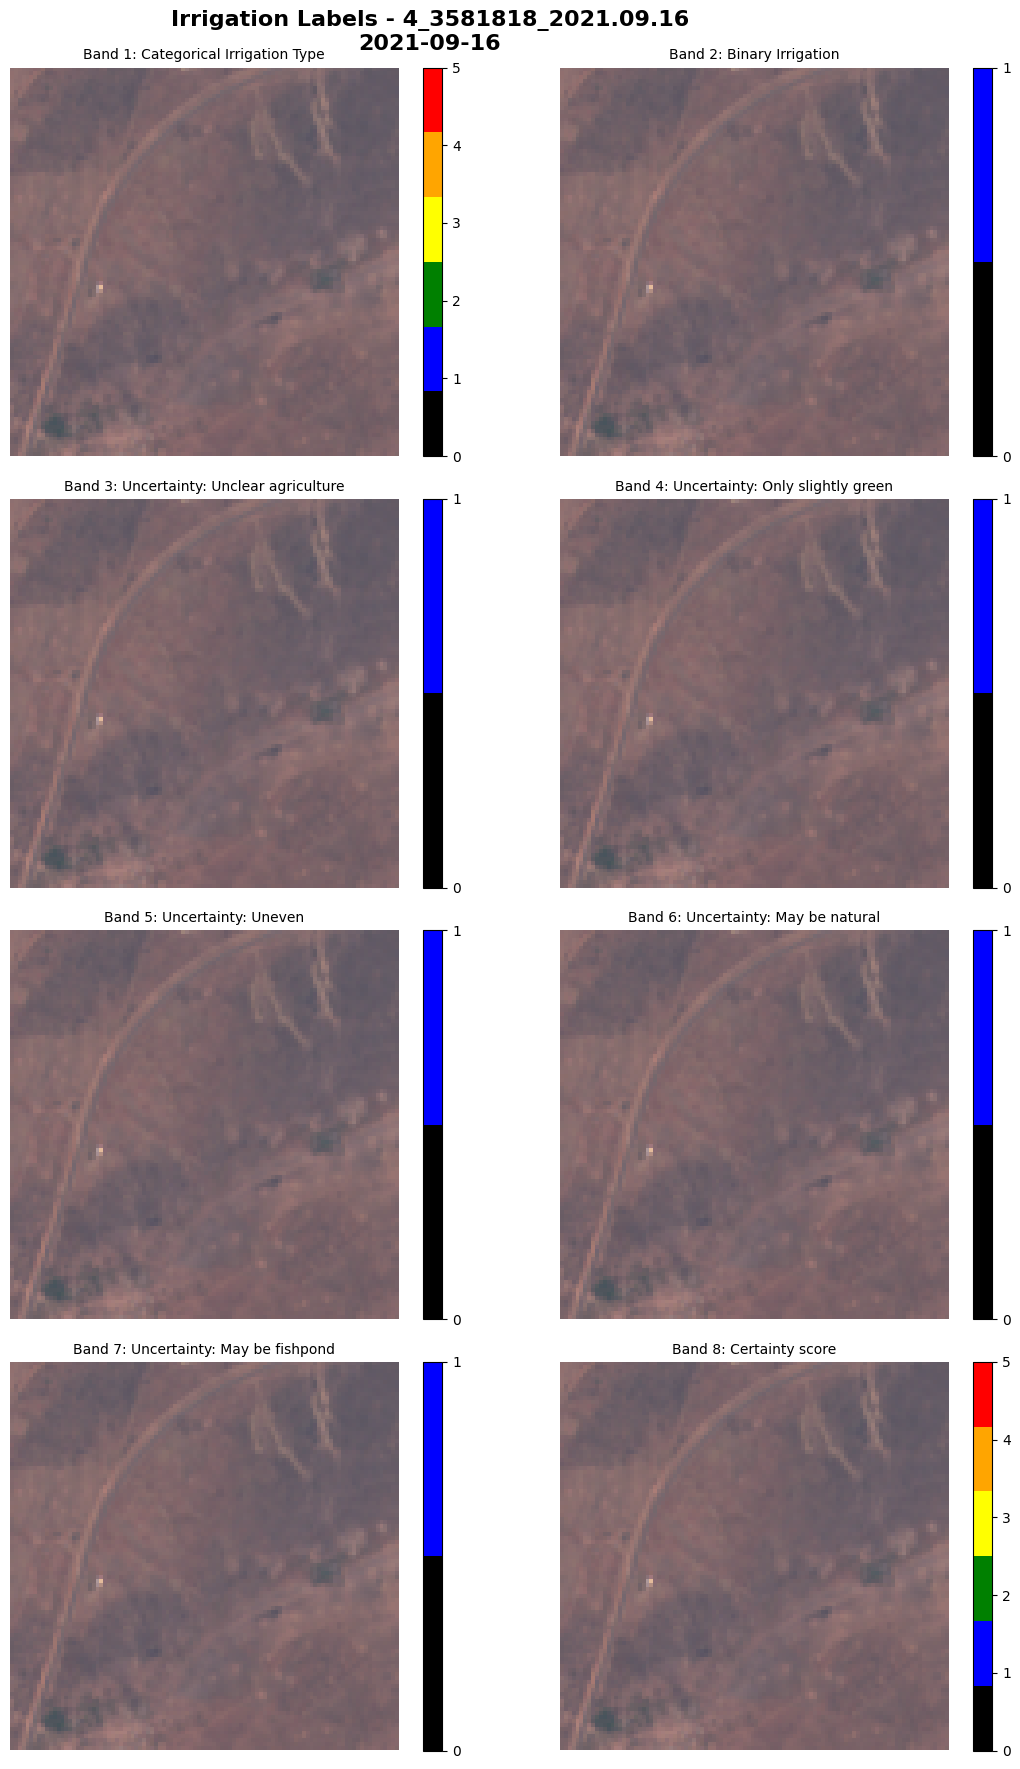

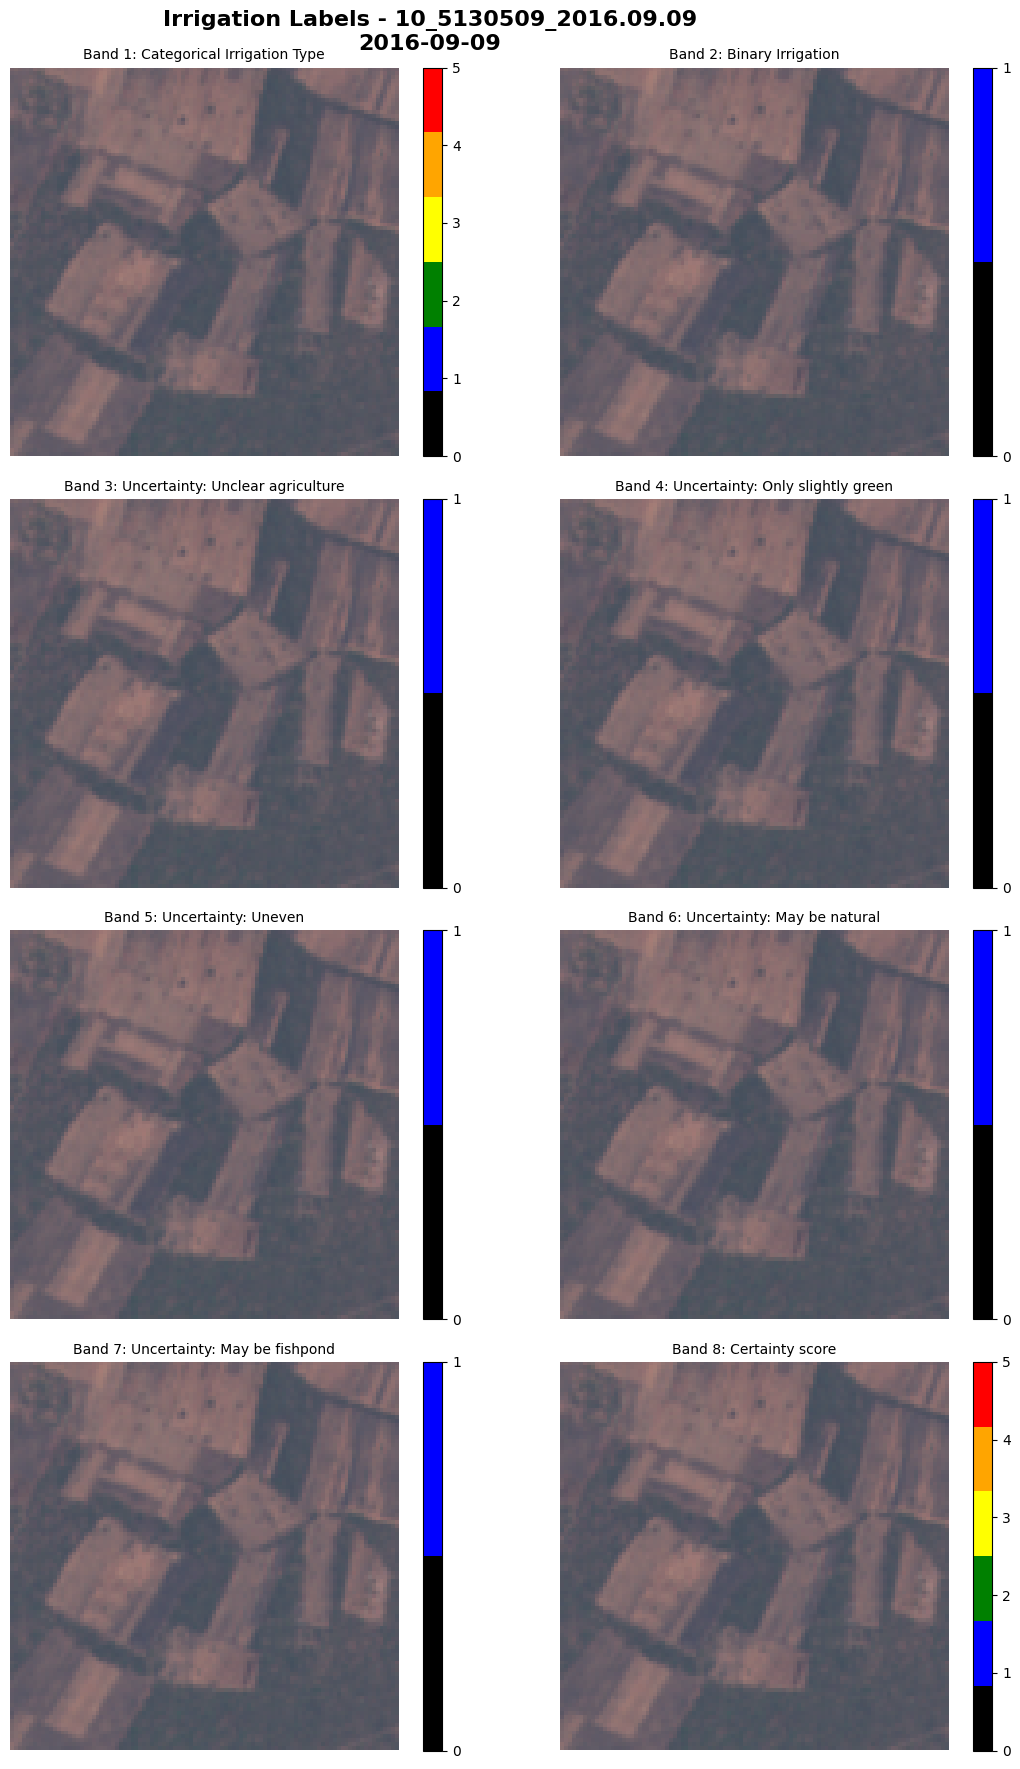

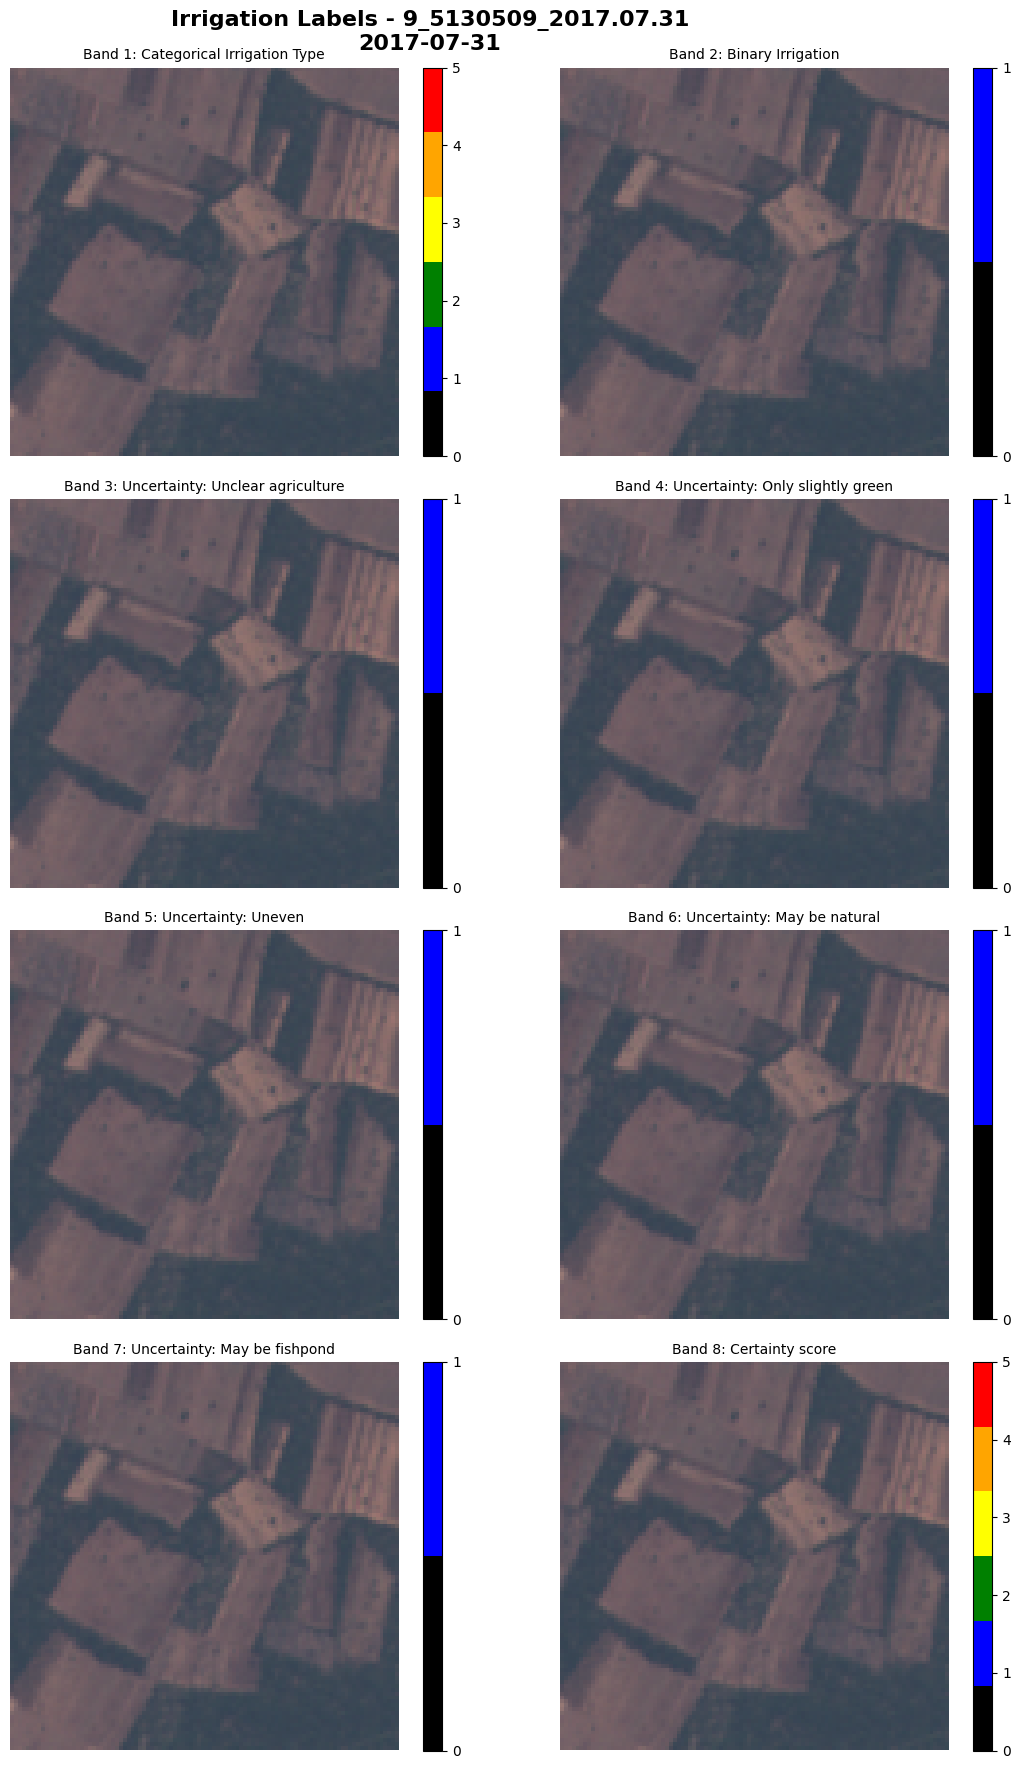

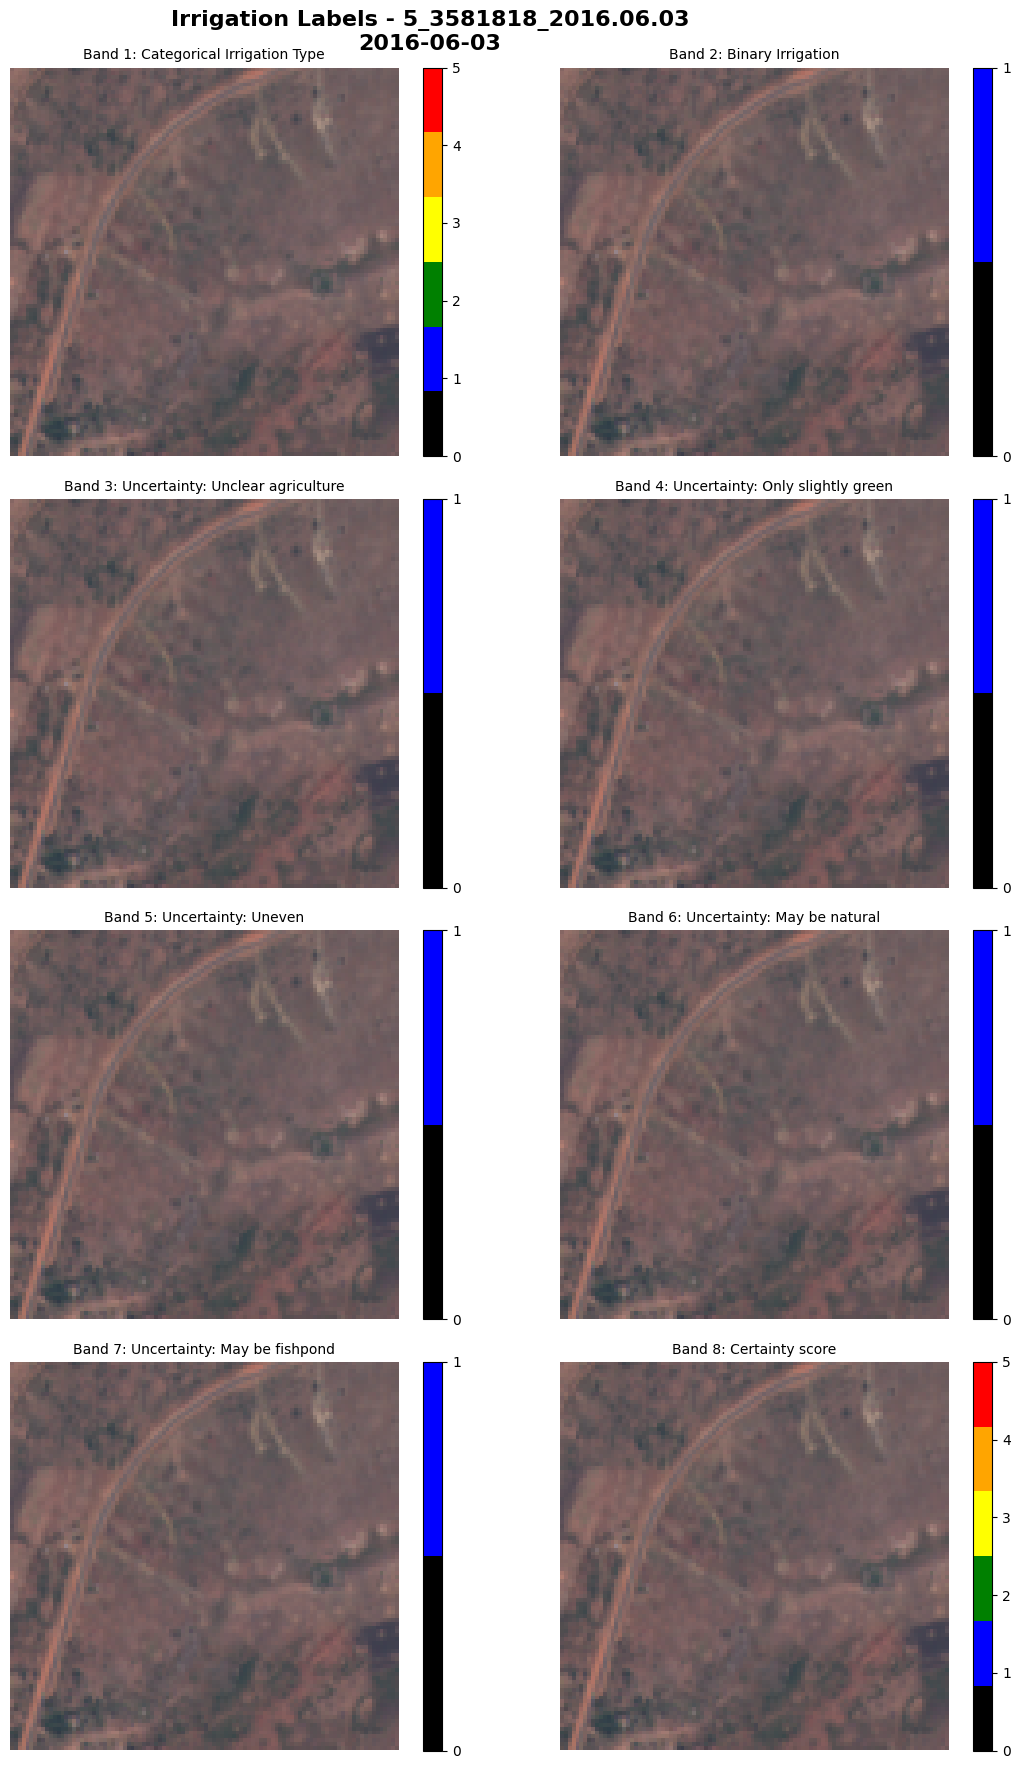

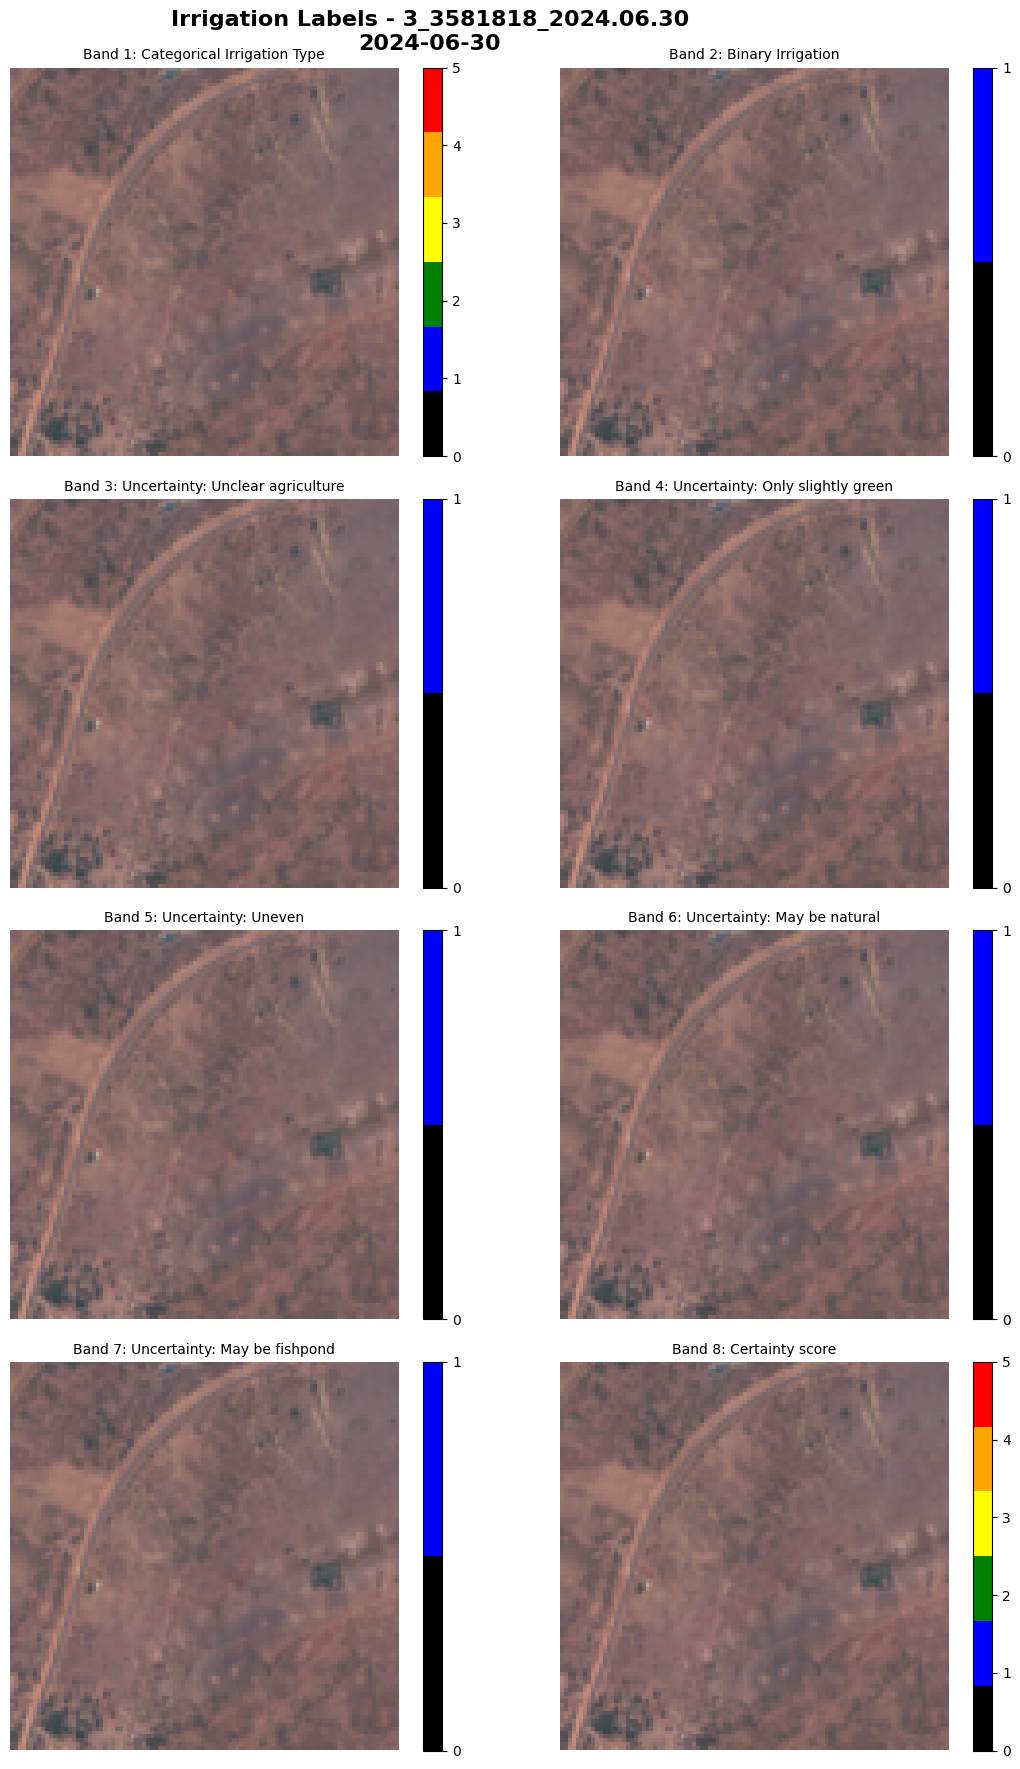

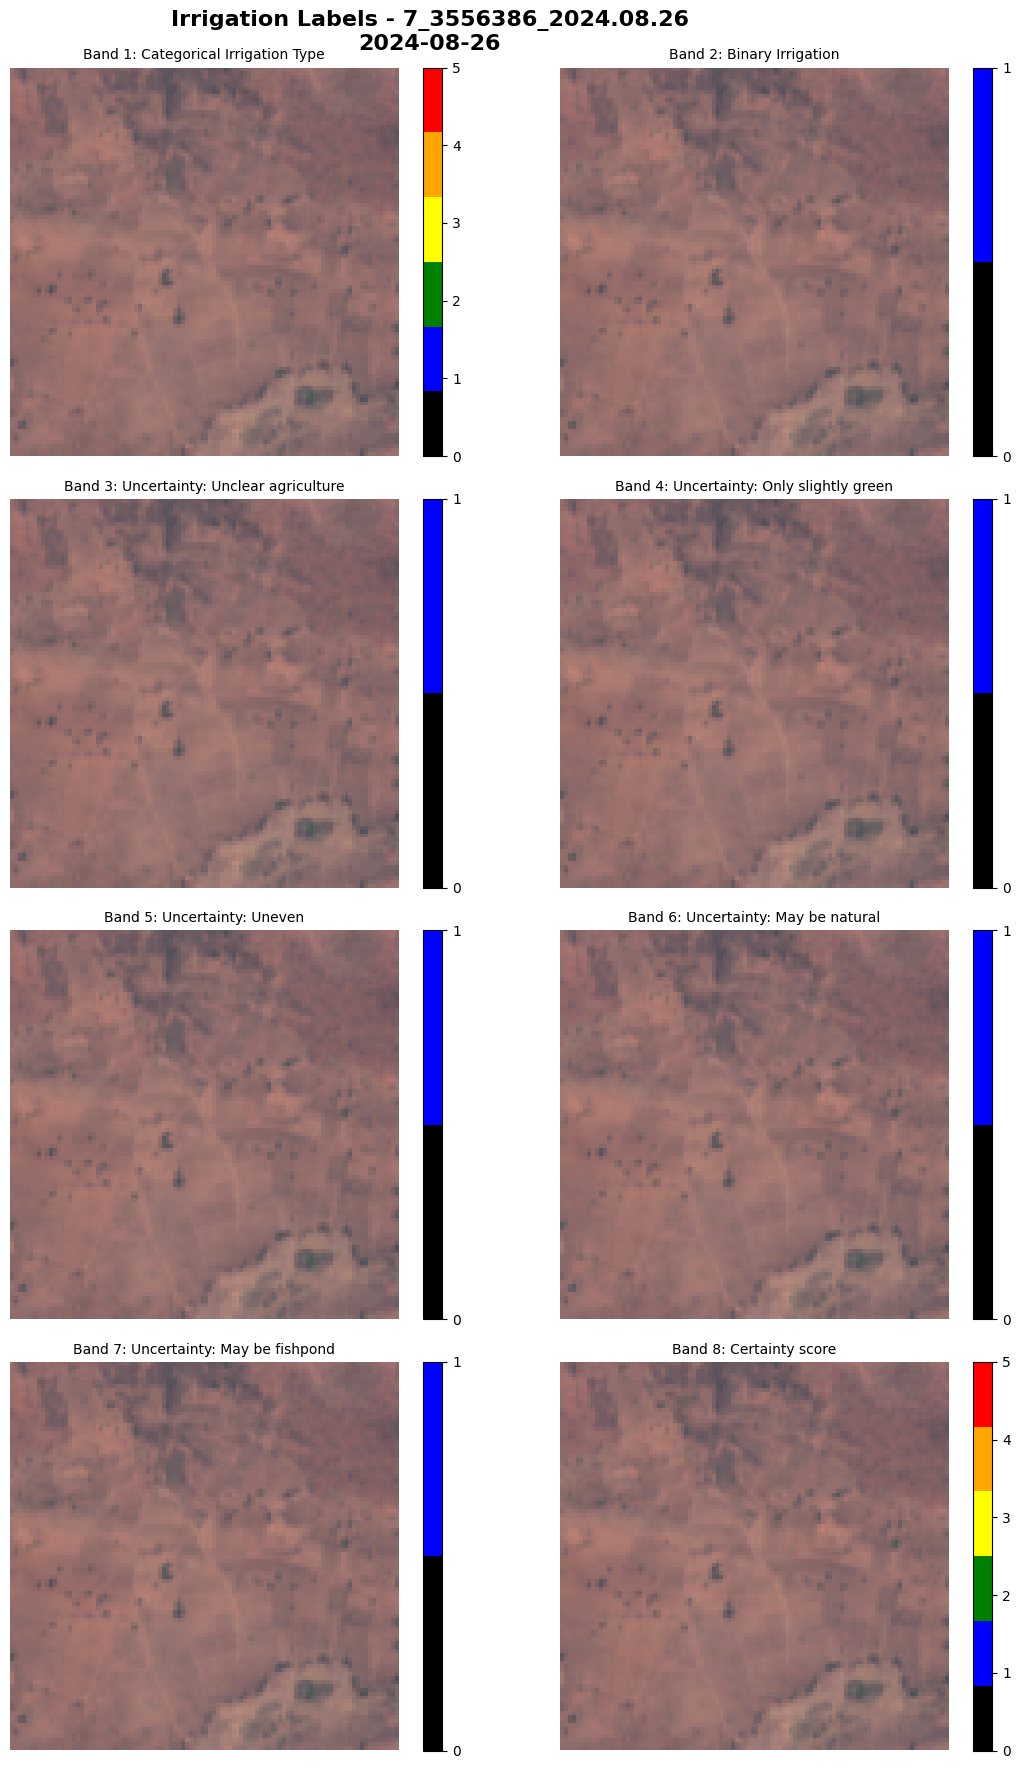

In [12]:
# Get most recent version folder
data_root = get_data_root()
features_dir = os.path.join(data_root, "features")
versions = sorted([d for d in os.listdir(features_dir) 
                   if os.path.isdir(os.path.join(features_dir, d))], reverse=True)
latest_version = os.path.join(features_dir, versions[0])

# Get first 10 label files
label_files = glob.glob(os.path.join(latest_version, "*_labels.tif"))[:10]

# Visualize each one
for labels_path in label_files:
    visualize_label_band(labels_path)